# Hamiltonian-based QML for Diabetes Prediction on PIMA (PennyLane)

Yes—**Hamiltonians** can be used naturally in QML for tabular prediction like PIMA.

This notebook implements a **Hamiltonian Feature Map**:
- build a **data-dependent Hamiltonian** \(H(x)\) from the (PCA-reduced) feature vector
- prepare a quantum state via **time evolution** \(\exp(-i H(x) t)\)
- apply a small **trainable variational head**
- train with **binary cross entropy** and evaluate with ROC/PR + threshold tuning

It also includes a classical Logistic Regression baseline.

> Dataset download uses **kagglehub** exactly as you provided.


* **02 HamVQC Noise-free**:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Megaantony00/qml-diabetes-nisq/blob/main/notebooks/02_hamvqc_noisefree.ipynb)

In [ ]:
import sys
import os

if 'google.colab' in sys.modules:
    !pip install -q pennylane>=0.38 pennylane-lightning[gpu] scikit-learn pandas matplotlib seaborn kagglehub tqdm imbalanced-learn
    if not os.path.exists('results'): os.makedirs('results')
    print("Environment configured for Colab.")
else:
    print("Environment configured for Local/Server usage.")

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pennylane as qml

# 1. DEFINIZIONE QUBIT E PARAMETRI FISSI
n_qubits = 8  # Cambia a 8 per la seconda run
n_components = n_qubits
n_layers = 2
alpha_zz = 0.5
trotter_steps = 1

save_folder = "Tesi_Risultati_Ham_8Qubits_noisy"

if not os.path.exists(save_folder):
    os.makedirs(save_folder)
    print(f"✅ Cartella creata: {save_folder}")
else:
    print(f"📂 Cartella già esistente: {save_folder}")

📂 Cartella già esistente: Tesi_Risultati_Ham_8Qubits_noisy


## 1) Imports

In [3]:
import os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import functools
from pennylane import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.linear_model import LogisticRegression

import pennylane as qml
from tqdm.auto import tqdm

np.random.seed(42)

## 2) Download dataset (KaggleHub)

In [4]:
import kagglehub

path = kagglehub.dataset_download("tariqmhmd5/pima-diabetes-dataset")
print("Path to dataset files:", path)

csv_candidates = glob.glob(str(Path(path) / "**" / "*.csv"), recursive=True)
print("CSV candidates:", csv_candidates)

if not csv_candidates:
    raise FileNotFoundError("No CSV file found in the KaggleHub dataset folder.")
csv_path = csv_candidates[0]
print("Using:", csv_path)

Path to dataset files: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1
CSV candidates: ['/home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv']
Using: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv


## 3) Load + preprocess

In [5]:
df = pd.read_csv(csv_path)
display(df.head())
print("Shape:", df.shape)

label_col = "Outcome" if "Outcome" in df.columns else df.columns[-1]
feature_cols = [c for c in df.columns if c != label_col]

X = df[feature_cols].copy()

# MODIFICA QUI: Mappiamo YES/NO in 1/0 prima di trasformare in int
if df[label_col].dtype == object:
    y = df[label_col].map({'YES': 1, 'NO': 0, 'yes': 1, 'no': 0}).astype(int).values
else:
    y = df[label_col].astype(int).values

# Sostituisci 0 con NaN dove indicato (normale per il dataset PIMA)
zero_as_missing = [c for c in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"] if c in X.columns]
X[zero_as_missing] = X[zero_as_missing].replace(0, np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.25, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X_train))
X_test = scaler.transform(imputer.transform(X_test))

print("Train:", X_train.shape, "Test:", X_test.shape)

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,YES
1,1,85,66,29,0,26.6,0.351,31,NO
2,8,183,64,0,0,23.3,0.672,32,YES
3,1,89,66,23,94,28.1,0.167,21,NO
4,0,137,40,35,168,43.1,2.288,33,YES


Shape: (768, 9)
Train: (576, 8) Test: (192, 8)


## 4) Reduce to qubits + map to angles

We reduce to **n_qubits** via PCA, then map to \([-\pi, \pi]\) so the Hamiltonian coefficients are well scaled.


In [6]:
#n_qubits = 4
#pca = PCA(n_components=n_qubits, random_state=42)
pca = PCA(n_components=n_components, random_state=42)

X_train_q = pca.fit_transform(X_train)
X_test_q = pca.transform(X_test)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Sum explained variance:", pca.explained_variance_ratio_.sum())

q_low, q_high = np.quantile(X_train_q, 0.05, axis=0), np.quantile(X_train_q, 0.95, axis=0)

def to_angles(X):
    Xc = np.clip(X, q_low, q_high)
    Xn = (Xc - q_low) / (q_high - q_low + 1e-9)  # [0,1]
    return (Xn * 2 - 1) * np.pi                  # [-pi, pi]

X_train_ang = to_angles(X_train_q)
X_test_ang = to_angles(X_test_q)

print("Angle range:", X_train_ang.min(), X_train_ang.max())

Explained variance ratio: [0.2587334  0.21608225 0.13172228 0.10518003 0.09884707 0.08674359
 0.05628148 0.04640991]
Sum explained variance: 1.0
Angle range: -3.141592653589793 3.141592652220357


## 5) Hamiltonian Feature Map + Variational Head

### Data Hamiltonian \(H(x)\)
A simple, effective choice is an Ising-like Hamiltonian whose coefficients are functions of the data:

\[
H(x) = \sum_i x_i Z_i + \alpha \sum_{i<j} x_i x_j Z_i Z_j
\]

Then we create the embedding with **time evolution**:

\[
|\phi(x)\rangle = e^{-i H(x) t} |+\rangle^{\otimes n}
\]

This is a “Hamiltonian embedding”: the *geometry* of states depends on \(H(x)\).

### Trainable head
We add a small hardware-efficient ansatz after the embedding and measure \(\langle Z_0 \rangle\), mapped to probability by a sigmoid.


In [7]:
import pennylane as qml
import pennylane.numpy as pnp # Fondamentale per i gradienti

# --- 1. CONFIGURAZIONE DEVICE CPU CON RUMORE ---
dev_noisy = qml.device("default.mixed", wires=n_qubits)

# --- 2. MODELLO DI RUMORE ---
fcond = qml.noise.op_in([qml.RX, qml.RY, qml.RZ, qml.Rot, qml.Hadamard])
noise_after_rot = qml.noise.partial_wires(qml.DepolarizingChannel, 0.01)

meas_cond = qml.noise.meas_eq(qml.expval)
readout_noise = qml.noise.partial_wires(qml.PhaseFlip, 0.02)

noise_model = qml.NoiseModel(
    {fcond: noise_after_rot},
    {meas_cond: readout_noise}
)

# --- 3. DEFINIZIONE DEL CIRCUITO E DELL'HAMILTONIANA ---
def data_hamiltonian(x, alpha=alpha_zz):
    coeffs = []
    ops = []
    # Termini locali Z
    for i in range(n_qubits):
        coeffs.append(x[i])
        ops.append(qml.PauliZ(i))
    # Termini a coppie ZZ (interazione)
    for i in range(n_qubits):
        for j in range(i+1, n_qubits):
            coeffs.append(alpha * x[i] * x[j])
            ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
    return qml.Hamiltonian(coeffs, ops)

def head_ansatz(weights):
    for l in range(n_layers):
        for i in range(n_qubits):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i+1) % n_qubits])

@functools.partial(qml.add_noise, noise_model=noise_model)
@qml.qnode(dev_noisy, interface="autograd")
def vqc_ham_node(x, weights):
    # Inizia nello stato |+> per aumentare l'espressività
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # Codifica dei dati tramite Evoluzione Temporale Hamiltoniana
    Hx = data_hamiltonian(x)
    qml.ApproxTimeEvolution(Hx, t_embed, trotter_steps)

    head_ansatz(weights)
    return qml.expval(qml.PauliZ(0))

# --- 4. FUNZIONI DI SUPPORTO PER L'ADDESTRAMENTO ---
def predict_proba(X, weights):
    # Usiamo pnp per mantenere il tracciamento dei gradienti
    logits = pnp.array([vqc_ham_node(x, weights) for x in X])
    return 1.0 / (1.0 + pnp.exp(-logits))

def bce(y_true, p_pred, eps=1e-9):
    p = pnp.clip(p_pred, eps, 1 - eps)
    return -pnp.mean(y_true * pnp.log(p) + (1 - y_true) * pnp.log(1 - p))

def cost(weights, Xb, yb):
    return bce(yb, predict_proba(Xb, weights))

### Train

In [8]:
# --- CELLA DI RECUPERO (RESUME) ---
import pickle
import os
import pandas as pd

# 1. SCRIVI QUI IL PERCORSO MANUALE (Copia il nome della cartella dal browser di Jupyter)
# Esempio: "Tesi_Risultati_Ham_8Qubits_noisy/multi_run_20240522_103045"
cartella_da_recuperare = "Tesi_Risultati_Ham_8Qubits_noisy/multi_run_20260306_102607" 

# Specifica quale t_val vuoi riprendere (es: "t_0.1")
t_da_riprendere = "t_0.1"

percorso_recupero = os.path.join(cartella_da_recuperare, t_da_riprendere) 
file_pesi = os.path.join(percorso_recupero, "best_weights.pkl")

if os.path.exists(file_pesi):
    with open(file_pesi, "rb") as f:
        weights = pickle.load(f)
    print(f"✅ Pesi caricati da {t_da_riprendere}! Ripartiamo dall'ultimo salvataggio.")
    
    # Carichiamo la history per sapere da che epoca ripartire
    history_old_df = pd.read_csv(os.path.join(percorso_recupero, "training_history.csv"))
    history = history_old_df.to_dict(orient="list")
    start_epoch = len(history["val_loss"]) + 1
    print(f"📈 Epoche già completate: {len(history['val_loss'])}. Ripartiremo dalla {start_epoch}.")
else:
    print("❌ File non trovato. Verranno usati pesi casuali e start_epoch = 1.")
    start_epoch = 1
    # Se non c'è recupero, inizializziamo una history vuota
    history = {"val_loss": [], "val_auc": [], "val_acc": []}

✅ Pesi caricati da t_0.1! Ripartiamo dall'ultimo salvataggio.
📈 Epoche già completate: 67. Ripartiremo dalla 68.


In [9]:
import os
import pandas as pd
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score
from pennylane import numpy as pnp

# --- CONFIGURAZIONE MULTI-RUN ---
t_values = [0.1, 0.5, 1.0]
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Usiamo la cartella locale
base_run_path = os.path.join(save_folder, f"multi_run_{timestamp}")
print(f"📂 I risultati verranno salvati in: {base_run_path}")

# Lista per creare la tabella riassuntiva finale
risultati_finali = []

for t_val in t_values:
    print(f"\n🚀 TEST: t_embed = {t_val}")
    current_run_path = os.path.join(base_run_path, f"t_{t_val}")
    os.makedirs(current_run_path, exist_ok=True)

    # 1. Reset parametri per ogni test
    global t_embed
    t_embed = t_val

    # Inizializzazione pesi
    weights = pnp.array(0.01 * pnp.random.randn(n_layers, n_qubits, 3), requires_grad=True)
    opt = qml.optimize.AdamOptimizer(stepsize=0.1)

    history = {"val_loss": [], "val_auc": [], "val_acc": []}

    # 2. Addestramento con SALVATAGGIO PROGRESSIVO
    epochs = 150
    batch_size = 24
    
    for epoch in range(start_epoch, epochs + 1):
        idx = np.random.permutation(len(X_train_ang))
        Xs, ys = X_train_ang[idx], y_train[idx]

        for start in range(0, len(Xs), batch_size):
            Xb, yb = Xs[start:start+batch_size], ys[start:start+batch_size]
            weights = opt.step(lambda w: cost(w, Xb, yb), weights)

        # Valutazione
        p_val = predict_proba(X_test_ang, weights)
        loss_v = bce(y_test, p_val)
        auc_v = roc_auc_score(y_test, p_val)
        acc_v = accuracy_score(y_test, (p_val >= 0.5).astype(int))

        history["val_loss"].append(loss_v)
        history["val_auc"].append(auc_v)
        history["val_acc"].append(acc_v)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | Loss: {loss_v:.4f} | AUC: {auc_v:.4f}")

        # --- SALVATAGGIO PROGRESSIVO AD OGNI EPOCA ---
        # Se il server crasha, la cartella NON sarà vuota!
        pd.DataFrame(history).to_csv(os.path.join(current_run_path, "training_history.csv"), index=False)
        with open(os.path.join(current_run_path, "best_weights.pkl"), "wb") as f:
            pickle.dump(weights, f)

    # 3. Fine run per questo t_val: Salvataggio Info e Grafico
    info_test = {
        "t_embed": t_val,
        "n_layers": n_layers,
        "n_qubits": n_qubits,
        "final_auc": history["val_auc"][-1],
        "final_loss": history["val_loss"][-1],
        "max_auc_reached": max(history["val_auc"]),
        "timestamp": timestamp
    }
    with open(os.path.join(current_run_path, "metriche_finali.pkl"), "wb") as f:
        pickle.dump(info_test, f)

    plt.figure()
    plt.plot(history["val_loss"], label="Loss")
    plt.plot(history["val_auc"], label="AUC")
    plt.title(f"Curve t={t_val} ({n_qubits} Qubits)")
    plt.legend()
    # Salva il grafico e poi chiudilo per non sovrapporlo agli altri
    plt.savefig(os.path.join(current_run_path, "learning_curves.png"))
    plt.close()
    
    # Aggiungiamo i dati per la tabella riassuntiva
    risultati_finali.append({
        "t_embed": t_val,
        "Max_AUC": max(history["val_auc"]),
        "Final_AUC": history["val_auc"][-1],
        "Final_Accuracy": history["val_acc"][-1]
    })

# --- 4. CREAZIONE E SALVATAGGIO TABELLA RIASSUNTIVA FINALE ---
df_finale = pd.DataFrame(risultati_finali)
path_tabella = os.path.join(base_run_path, "riassunto_t_values.csv")
df_finale.to_csv(path_tabella, index=False)

print(f"\n✅ TUTTO COMPLETATO! I risultati sono in: {base_run_path}")
print("📊 Tabella riassuntiva dei 3 test:")
display(df_finale)

📂 I risultati verranno salvati in: Tesi_Risultati_Ham_8Qubits_noisy/multi_run_20260306_212231

🚀 TEST: t_embed = 0.1
Epoch  70 | Loss: 0.6392 | AUC: 0.6693
Epoch  80 | Loss: 0.6205 | AUC: 0.7422
Epoch  90 | Loss: 0.6225 | AUC: 0.7337
Epoch 100 | Loss: 0.6252 | AUC: 0.7496
Epoch 110 | Loss: 0.6207 | AUC: 0.7482
Epoch 120 | Loss: 0.6266 | AUC: 0.7272
Epoch 130 | Loss: 0.6184 | AUC: 0.7550
Epoch 140 | Loss: 0.6252 | AUC: 0.7355
Epoch 150 | Loss: 0.6208 | AUC: 0.7513

🚀 TEST: t_embed = 0.5
Epoch  70 | Loss: 0.6845 | AUC: 0.4967
Epoch  80 | Loss: 0.6745 | AUC: 0.5537
Epoch  90 | Loss: 0.6709 | AUC: 0.5887
Epoch 100 | Loss: 0.6635 | AUC: 0.6322
Epoch 110 | Loss: 0.6626 | AUC: 0.6362
Epoch 120 | Loss: 0.6617 | AUC: 0.6512
Epoch 130 | Loss: 0.6659 | AUC: 0.6351
Epoch 140 | Loss: 0.6642 | AUC: 0.6199
Epoch 150 | Loss: 0.6641 | AUC: 0.6392

🚀 TEST: t_embed = 1.0
Epoch  70 | Loss: 0.6937 | AUC: 0.4789
Epoch  80 | Loss: 0.6831 | AUC: 0.5506
Epoch  90 | Loss: 0.6854 | AUC: 0.5266
Epoch 100 | Loss: 

,t_embed,Max_AUC,Final_AUC,Final_Accuracy
0,0.1,0.768119,0.751284,0.713542
1,0.5,0.661254,0.639164,0.661458
2,1.0,0.620896,0.568000,0.598958


### Learning curves

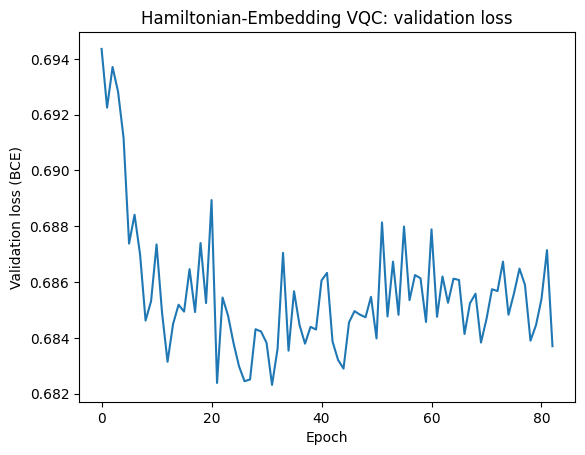

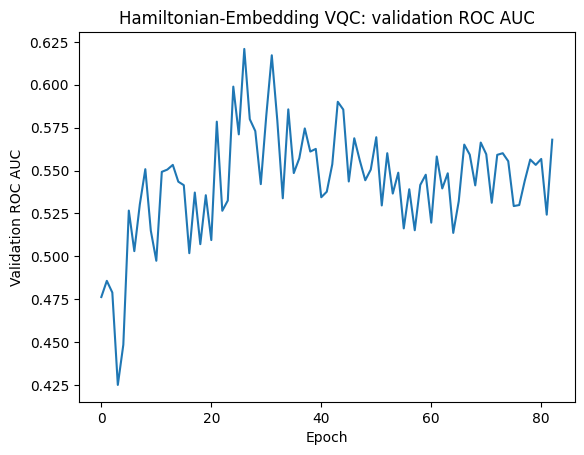

In [10]:
plt.figure()
plt.plot(history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Validation loss (BCE)")
plt.title("Hamiltonian-Embedding VQC: validation loss")
plt.show()

plt.figure()
plt.plot(history["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("Validation ROC AUC")
plt.title("Hamiltonian-Embedding VQC: validation ROC AUC")
plt.show()

## 6) Evaluation + Threshold tuning

Test ROC AUC: 0.5680000000000001
Test Average Precision (PR AUC): 0.4000033109890725


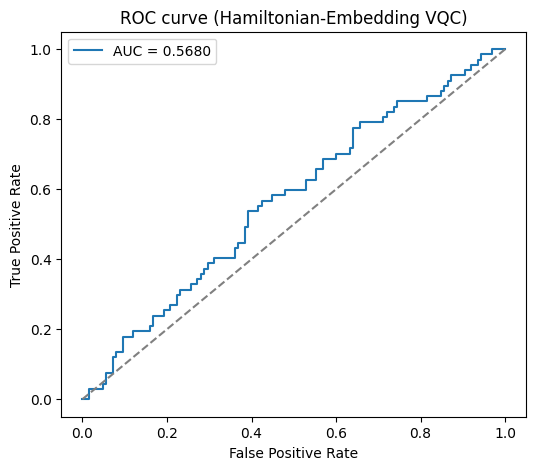

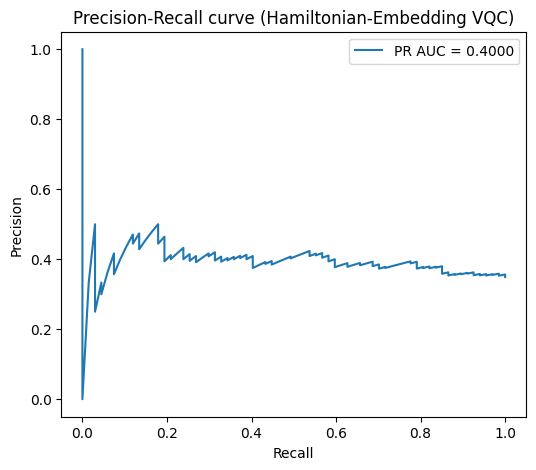

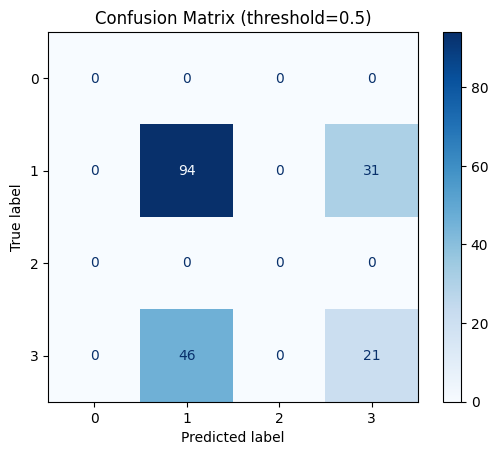

Accuracy (0.5): 0.5989583333333334
F1 (0.5): 0.35294117647058826
Best threshold (by F1): 0.45 | Best F1: 0.5255


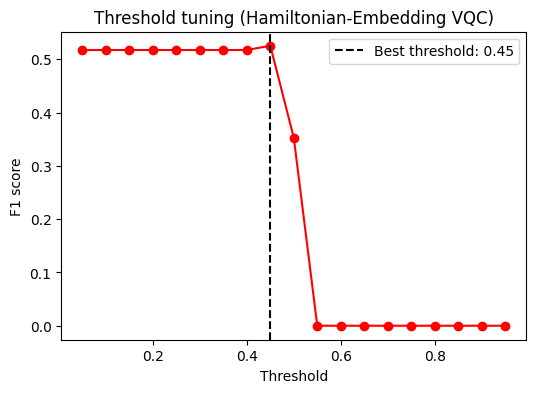

In [11]:
# Usiamo i nomi corretti: X_test_ang e y_test
p_test = predict_proba(X_test_ang, weights)
auc = roc_auc_score(y_test, p_test)
ap = average_precision_score(y_test, p_test)
print("Test ROC AUC:", auc)
print("Test Average Precision (PR AUC):", ap)

# ROC Curve
fpr, tpr, thr = roc_curve(y_test, p_test)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (Hamiltonian-Embedding VQC)")
plt.legend()
plt.show()

#

# PR Curve
prec, rec, thr_pr = precision_recall_curve(y_test, p_test)
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f'PR AUC = {ap:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve (Hamiltonian-Embedding VQC)")
plt.legend()
plt.show()

# Confusion matrix at 0.5
y_pred_05 = (p_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_05)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix (threshold=0.5)")
plt.show()

#

print("Accuracy (0.5):", accuracy_score(y_test, y_pred_05))
print("F1 (0.5):", f1_score(y_test, y_pred_05))

# Threshold tuning
thresholds = np.linspace(0.05, 0.95, 19)
f1s = []
for t in thresholds:
    f1s.append(f1_score(y_test, (p_test >= t).astype(int)))
best_i = int(np.argmax(f1s))
best_t = thresholds[best_i]
print(f"Best threshold (by F1): {best_t:.2f} | Best F1: {f1s[best_i]:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1s, marker="o", color='red')
plt.axvline(best_t, color='black', linestyle='--', label=f'Best threshold: {best_t:.2f}')
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("Threshold tuning (Hamiltonian-Embedding VQC)")
plt.legend()
plt.show()

## 7) Classical baseline (Logistic Regression)

In [12]:
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train, y_train)
p_lr = clf.predict_proba(X_test)[:, 1]

print("LogReg ROC AUC:", roc_auc_score(y_test, p_lr))
print("LogReg AP (PR AUC):", average_precision_score(y_test, p_lr))
print("LogReg Acc:", accuracy_score(y_test, (p_lr >= 0.5).astype(int)))

LogReg ROC AUC: 0.8329552238805971
LogReg AP (PR AUC): 0.7173014414794692
LogReg Acc: 0.7604166666666666


## 8) Research knobs to explore (Hamiltonian-centric)

Try these to turn this into a solid research study:

1. **Hamiltonian design**
   - add non-commuting terms: \(\sum_i x_i X_i\), \(\sum_{i<j} \beta X_i X_j\)  
   - use sparse vs dense couplings  
   - compare Ising-only vs mixed XYZ

2. **Embedding dynamics**
   - tune **evolution time** \(t\) (fixed vs trainable)  
   - increase **Trotter steps** vs shallow circuits  
   - different initial states (|0>, |+>, random product states)

3. **Readout**
   - measure multiple observables \(\langle Z_i \rangle\) and train a classical linear head  
   - use energy-based readout: minimize \(\langle H_{class} \rangle\)

4. **Compare paradigms**
   - AngleEmbedding VQC vs **Hamiltonian embedding VQC** (this notebook)  
   - Quantum kernel using fidelity of Hamiltonian-evolved states  
   - Hamiltonian reservoir computing (fixed H, train only readout)

5. **Robust evaluation**
   - k-fold CV, calibration curves, and clinically relevant metrics (sensitivity/specificity)


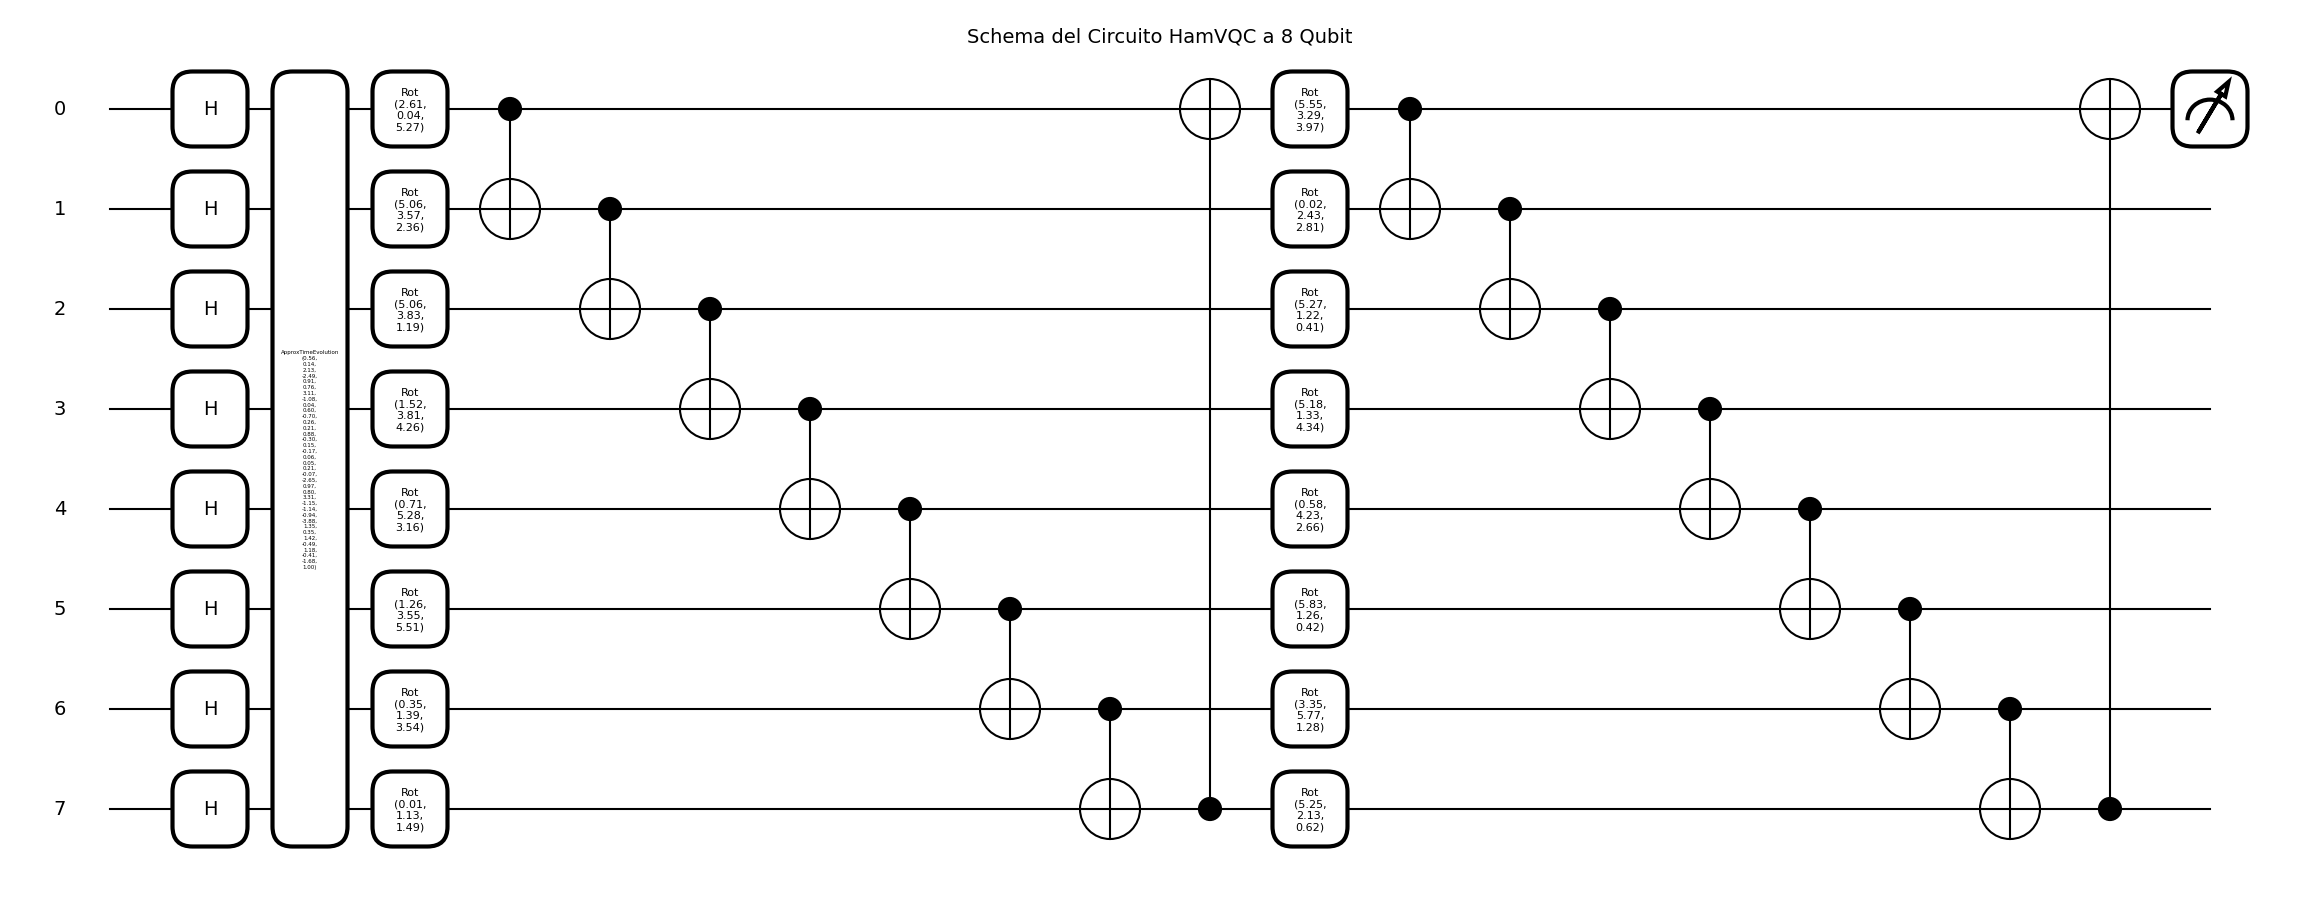

✅ Immagine 'schema_hamvQC_8qubit.png' generata!


In [14]:

import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np

# --- 1. SETTAGGIO PARAMETRI (8 QUBIT) ---
n_q = 8
n_l = 2
ALPHA_ZZ = 0.5
T_EMBED = 1.0
TROTTER_STEPS = 1

# --- 2. DEFINIZIONE FUNZIONI PER IL DISEGNO ---
def head_ansatz(weights):
    for l in range(n_l):
        for i in range(n_q):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)
        for i in range(n_q):
            qml.CNOT(wires=[i, (i+1) % n_q])

def data_hamiltonian(x, alpha=ALPHA_ZZ):
    coeffs = []
    ops = []
    for i in range(n_q):
        coeffs.append(x[i])
        ops.append(qml.PauliZ(i))
    for i in range(n_q):
        for j in range(i+1, n_q):
            coeffs.append(alpha * x[i] * x[j])
            ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
    return qml.Hamiltonian(coeffs, ops)

# Device fittizio per il disegno
dev_draw = qml.device("default.qubit", wires=n_q)

@qml.qnode(dev_draw)
def vqc_hamiltonian_disegno(x, weights):
    for i in range(n_q):
        qml.Hadamard(wires=i)
    Hx = data_hamiltonian(x)
    qml.ApproxTimeEvolution(Hx, T_EMBED, TROTTER_STEPS)
    head_ansatz(weights)
    return qml.expval(qml.PauliZ(0))

# --- 3. GENERAZIONE DELLO SCHEMA ---
weights_sample = np.random.uniform(0, 2 * np.pi, (n_l, n_q, 3))
x_sample = np.random.uniform(-np.pi, np.pi, (n_q,))

fig, ax = qml.draw_mpl(vqc_hamiltonian_disegno, decimals=2)(x_sample, weights_sample)
fig.suptitle(f"Schema del Circuito HamVQC a 8 Qubit", fontsize=14)

plt.savefig("schema_hamvQC_8qubit.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Immagine 'schema_hamvQC_8qubit.png' generata!")